## Plusieurs sections du notebook reprennent des parties de code issues du dépôt GitHub : https://github.com/ageron/handson-ml2

In [1]:
import os
import pandas as pd
import numpy as np

# On fixe la graine aléatoire
np.random.seed(42)

# Projet ML bout-en-bout
## Prédire le prix des maisons en Californie à partir de données sur la population, le revenu moyen, le prix médian des maisons par quartier

## Quadrage du problème
La première question à se poser et à quoi va servir ce modèle. Dans certains cas, un modèle de prédiction automatique peut être l'objectif finale mais dans d'autres il peut être une étape intermédiaire. Connaître l'objectif va permettre de sélectionner le type d'algorithme de Machine Learning à évaluer. Dans le cas présent ce sera un modèle de régression.

## Obtenir de la donnée

In [2]:
datapath = os.path.join("../datasets", "housing", "housing.csv")
housing = pd.read_csv(datapath)
housing.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [3]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [4]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [5]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
housing[['longitude']].apply(lambda x: np.quantile(x, 0.1))

longitude   -122.29
dtype: float64

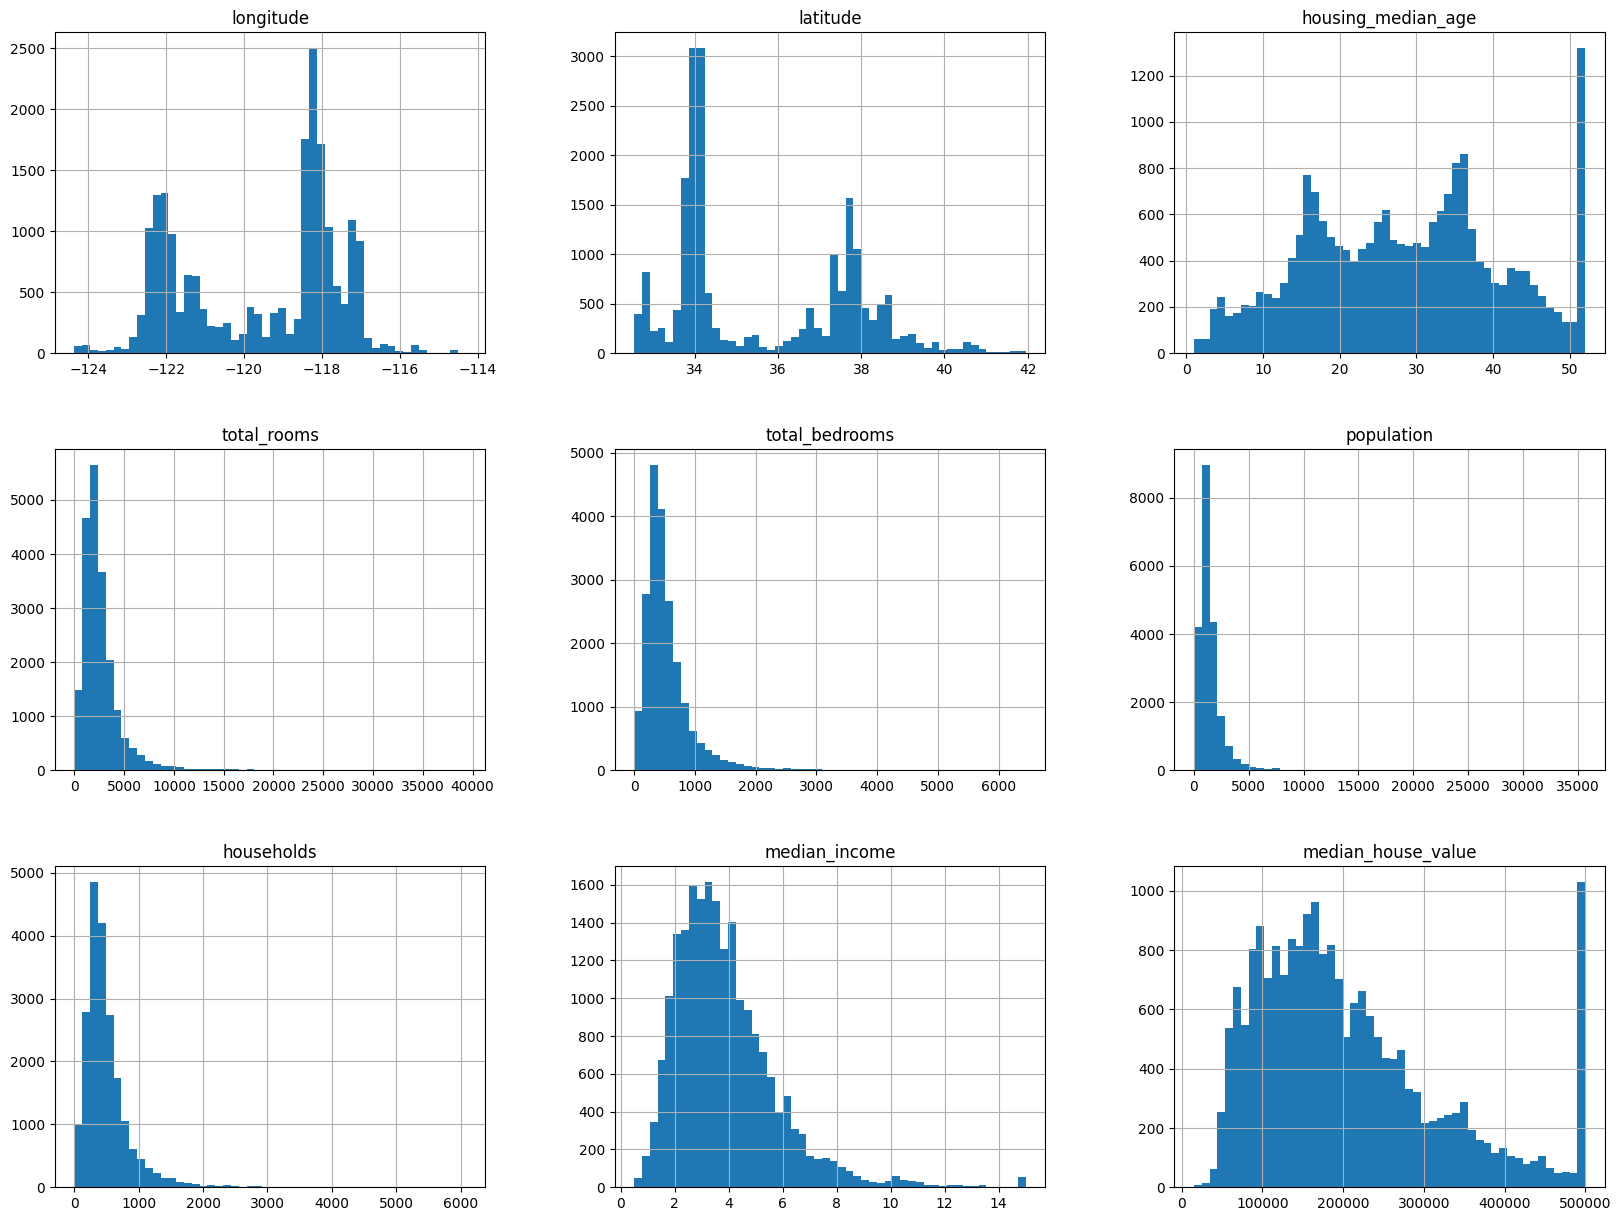

In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
housing.hist(bins=50, figsize=(20,15))
plt.show()

In [8]:
housing.shape

(20640, 10)

In [9]:
housing.loc[housing['median_house_value']>= 500001]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
89,-122.27,37.80,52.0,249.0,78.0,396.0,85.0,1.2434,500001.0,NEAR BAY
459,-122.25,37.87,52.0,609.0,236.0,1349.0,250.0,1.1696,500001.0,NEAR BAY
493,-122.24,37.86,52.0,1668.0,225.0,517.0,214.0,7.8521,500001.0,NEAR BAY
494,-122.24,37.85,52.0,3726.0,474.0,1366.0,496.0,9.3959,500001.0,NEAR BAY
509,-122.23,37.83,52.0,2990.0,379.0,947.0,361.0,7.8772,500001.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20422,-118.90,34.14,35.0,1503.0,263.0,576.0,216.0,5.1457,500001.0,<1H OCEAN
20426,-118.69,34.18,11.0,1177.0,138.0,415.0,119.0,10.0472,500001.0,<1H OCEAN
20427,-118.80,34.19,4.0,15572.0,2222.0,5495.0,2152.0,8.6499,500001.0,<1H OCEAN
20436,-118.69,34.21,10.0,3663.0,409.0,1179.0,371.0,12.5420,500001.0,<1H OCEAN


In [10]:
housing.loc[housing['housing_median_age']>=52.0]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20142,-119.06,34.36,52.0,1239.0,320.0,934.0,298.0,1.8618,183300.0,<1H OCEAN
20220,-119.27,34.28,52.0,2239.0,420.0,941.0,397.0,4.1250,349000.0,NEAR OCEAN
20236,-119.27,34.27,52.0,459.0,112.0,276.0,107.0,2.3750,198400.0,NEAR OCEAN
20237,-119.27,34.27,52.0,1577.0,343.0,836.0,335.0,3.5893,206600.0,NEAR OCEAN


## Visualisation de la donnée

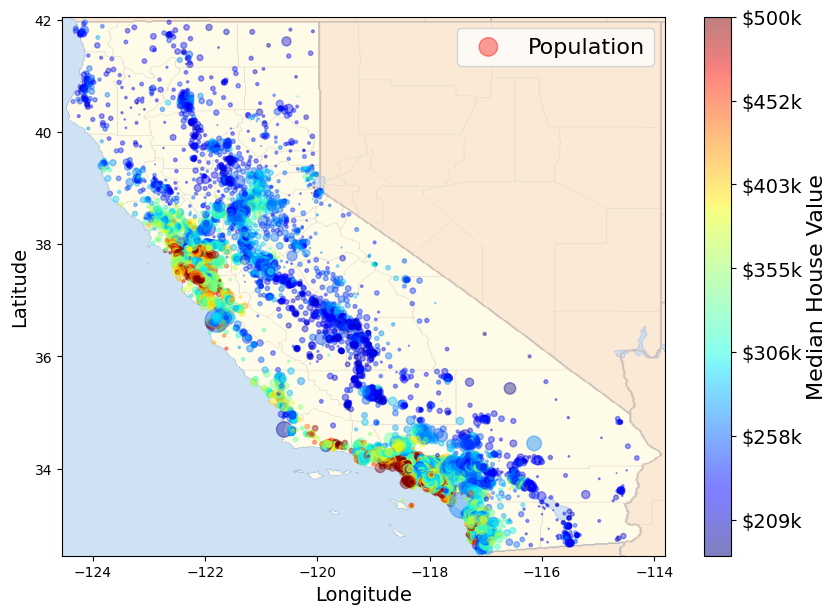

In [11]:
import matplotlib.image as mpimg
california_img=mpimg.imread(os.path.join("../datasets", "housing", "california.png"))
ax = housing.plot(kind="scatter", x="longitude", y="latitude", figsize=(10,7),
                  s=housing['population']/100, label="Population",
                  c="median_house_value", cmap=plt.get_cmap("jet"),
                  colorbar=False, alpha=0.4)
plt.imshow(california_img, extent=[-124.55, -113.80, 32.45, 42.05], alpha=0.5,
           cmap=plt.get_cmap("jet"))
plt.ylabel("Latitude", fontsize=14)
plt.xlabel("Longitude", fontsize=14)

prices = housing["median_house_value"]
tick_values = np.linspace(prices.min(), prices.max(), 11)
cbar = plt.colorbar(ticks=tick_values/prices.max())
cbar.ax.set_yticklabels(["$%dk"%(round(v/1000)) for v in tick_values], fontsize=14)
cbar.set_label('Median House Value', fontsize=16)

plt.legend(fontsize=16)
plt.show()

## Analyse exploratoire multivariée : recherche de corrélation
Corrélation de Pearson : https://en.wikipedia.org/wiki/Pearson_correlation_coefficient

In [12]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


In [13]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

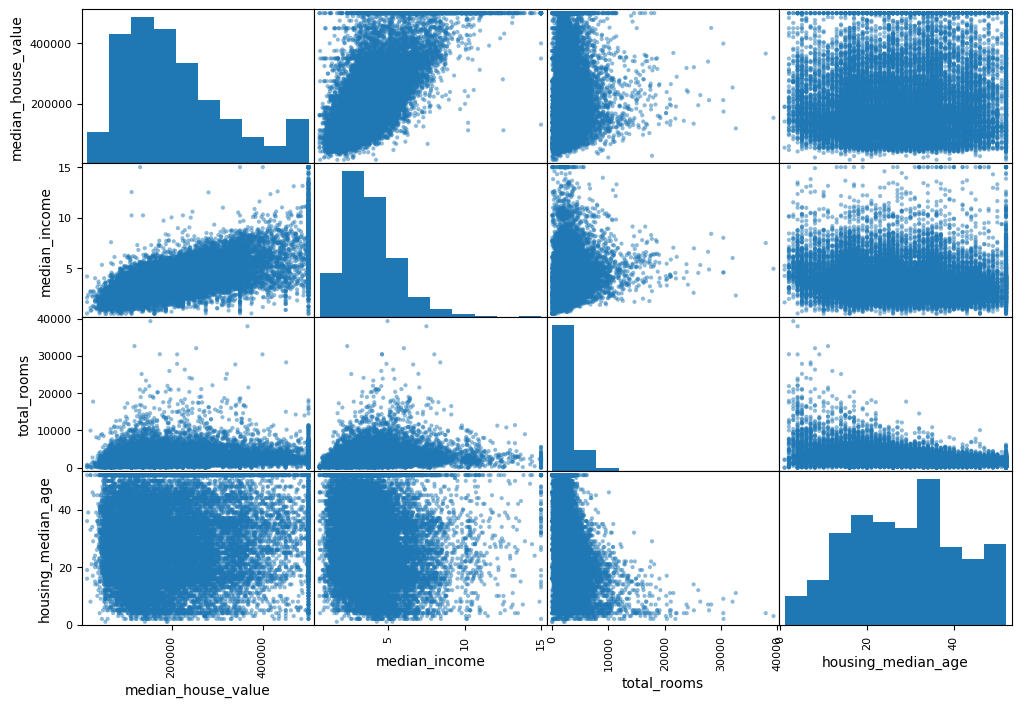

In [14]:
from pandas.plotting import scatter_matrix
attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))

### On remarque une "ligne" à 500k$. Il est préférable de supprimer ces artéfacts afin de ne pas perturber l'apprentissage des modèles

<Axes: xlabel='median_income', ylabel='median_house_value'>

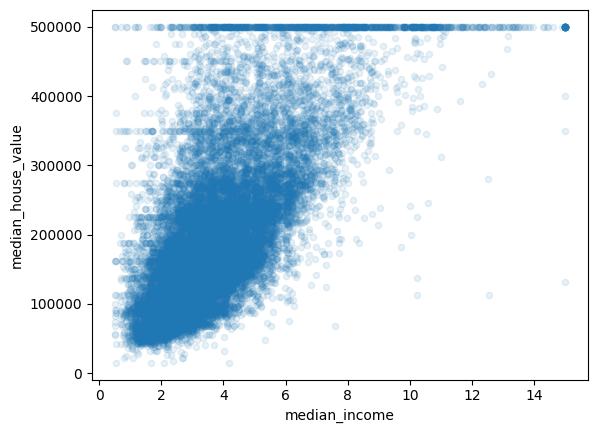

In [15]:
housing.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1)

In [16]:
print(housing.shape[0])  # Avant

20640


<Axes: xlabel='median_income', ylabel='median_house_value'>

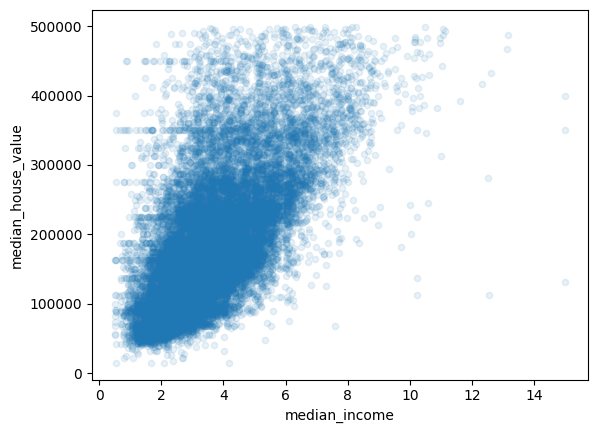

In [17]:
housing = housing[housing['median_house_value'] < 500_000]
housing.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1)

In [18]:
print(housing.shape[0])  # Après. Suppression de 992 quartiers

19648


## Feature engineering
Combinaison de caractéristiques plus informatives

In [19]:
housing["rooms_per_household"] = housing["total_rooms"]/housing["households"]  # nombre de pièces par maison
housing["bedrooms_per_room"] = housing["total_bedrooms"]/housing["total_rooms"]  # nombre de chambres par rapport au pièces
housing["population_per_household"]=housing["population"]/housing["households"]  # nombre de personnes par maison

In [20]:
corr_matrix = housing.corr(numeric_only=True)
corr_matrix["median_house_value"].sort_values(ascending=False).abs()

median_house_value          1.000000
median_income               0.646719
total_rooms                 0.144988
rooms_per_household         0.111581
households                  0.095634
total_bedrooms              0.075219
housing_median_age          0.065139
population                  0.013592
population_per_household    0.021205
longitude                   0.045733
latitude                    0.149257
bedrooms_per_room           0.220030
Name: median_house_value, dtype: float64

## Préparation de la donnée pour les algorithmes de Machine Learning

### Gestion des valeurs manquantes
La très grande majorité des algorithmes ne peuvent fonctionner avec des valeurs manquantes.
3 options possibles pour gérer les valeurs manquantes :
- Supprimer les exemples ayant des valeurs
- Supprimer la colonne complètement
- Remplacer les valeurs manquantes (par zéro, la moyenne, la médiane, la veleur la plus fréquente, etc.)

### option 1 : supprimer les lignes ayant des nan
```python
housing.dropna(subset=["total_bedrooms"])  
```

### option 2 : supprimer la colonne
```python
housing.drop("total_bedrooms", axis=1)
```

### L'option 3 : Remplacer les nan. Attention pour cette méthode, il faut calculer la valeur médiane sur les données d'apprentissage et l'appliquer sur tous les autres datasets
```python
median = housing["total_bedrooms"].median()
housing["total_bedrooms"].fillna(median, inplace=True)
```

### L'option 3 est la technique dite d'<I>imputing</I>. Trpouver une règle métier afin de trouver des valeurs de remplacements.

In [21]:
housing.isna().mean()

longitude                   0.000000
latitude                    0.000000
housing_median_age          0.000000
total_rooms                 0.000000
total_bedrooms              0.010179
population                  0.000000
households                  0.000000
median_income               0.000000
median_house_value          0.000000
ocean_proximity             0.000000
rooms_per_household         0.000000
bedrooms_per_room           0.010179
population_per_household    0.000000
dtype: float64

In [22]:
# Option 1 choisie
print(housing.shape[0])  # Avant
housing = housing.dropna()
print(housing.shape[0])  # Après. Suppression de 200 quartiers

19648
19448


### Gestion des données catégorielles
Les algorithmes de Machine Learning ne peuvent gérer les données catégorielles. Le one hot encoding (<a href="https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html">```OneHotEncoder```</a>) est l'une des meilleurs façon de transformer les données catégorielles en données numériques.
Son principe consiste à créer une colonne binaire par catégorie.
Une autre façon plus simple est de rattacher une valeur par catégorie mais cela a le défaut de rapprocher artificiellement des catégories ayant des valeurs proches. Cette méthode est le ordinal encoder : <a href="https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html">```OrdinalEncoder```</a>.

In [23]:
housing["ocean_proximity"]

0        NEAR BAY
1        NEAR BAY
2        NEAR BAY
3        NEAR BAY
4        NEAR BAY
           ...   
20635      INLAND
20636      INLAND
20637      INLAND
20638      INLAND
20639      INLAND
Name: ocean_proximity, Length: 19448, dtype: str

In [24]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     8496
INLAND        6468
NEAR OCEAN    2410
NEAR BAY      2069
ISLAND           5
Name: count, dtype: int64

In [25]:
# Méthode à utiliser dans le cas où les catégories peuvent être ordonnées : Ordinal Encoding

from sklearn.preprocessing import OrdinalEncoder

ordinal_encoder = OrdinalEncoder()
ordinal_encoder.fit_transform(housing[["ocean_proximity"]])

array([[3.],
       [3.],
       [3.],
       ...,
       [1.],
       [1.],
       [1.]], shape=(19448, 1))

In [26]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [27]:
# Méthode du one hot enconding est celle qui sera utilisée pour ce projet
from sklearn.preprocessing import OneHotEncoder

one_hot_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = one_hot_encoder.fit_transform(housing[["ocean_proximity"]])
housing_cat_1hot

array([[0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       ...,
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.]], shape=(19448, 5))

In [28]:
one_hot_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

#### A savoir que le one-hot-encoding est pratique quand le nombre de catégories est limité. Dans le cas où le nombre est grand (traitement du texte), il existe des techniques appellées <i>embedding</i>

## Mise à l'échelle des données (Feature Scaling)
L'une des transformations les plus importantes est la mise à l'échelle. Dans de rares cas, les algorithmes de Machine Learning ne fonctionne pas avec des données ayant des valeurs ayant des plages très différentes.
Dans la plupart des cas, remettre à l'échelle les labels n'est pas requis.
Les deux mises à l'échelle les plus connues sont :
- <i>Min-Max scaling</i> (appelé également <i>Normalization</i>) : $$ z = \frac{x-min(x)}{max(x)-min(x)} $$
- <i>Standardization</i> : $$ z = \frac{x-\mu}{\sigma} $$

In [29]:
housing.dtypes

longitude                   float64
latitude                    float64
housing_median_age          float64
total_rooms                 float64
total_bedrooms              float64
population                  float64
households                  float64
median_income               float64
median_house_value          float64
ocean_proximity                 str
rooms_per_household         float64
bedrooms_per_room           float64
population_per_household    float64
dtype: object

In [30]:
housing.select_dtypes(include=np.float64)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,6.281853,0.172096,2.181467
...,...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,5.045455,0.224625,2.560606
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,6.114035,0.215208,3.122807
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,5.205543,0.215173,2.325635
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,5.329513,0.219892,2.123209


## La mise à l'échelle nécessite de faire le split train/test

In [31]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing, train_size=0.8, random_state=42) 

In [32]:
# Min-Max Scaling
from sklearn.preprocessing import MinMaxScaler

min_max_scaler = MinMaxScaler()
z = min_max_scaler.fit_transform(housing.select_dtypes(include=np.float64))
pd.DataFrame(data=z, columns = train_set.select_dtypes(include=np.float64).columns).describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
count,19448.000000,19448.000000,19448.000000,19448.000000,19448.000000,19448.000000,19448.000000,19448.000000,19448.000000,19448.000000,19448.000000,19448.000000
mean,0.476745,0.330868,0.536563,0.066613,0.083447,0.040300,0.082089,0.219068,0.365665,0.034306,0.127703,0.001936
std,0.199790,0.228535,0.245299,0.055597,0.065583,0.032087,0.063048,0.108246,0.200569,0.017475,0.063247,0.008605
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.257968,0.147715,0.333333,0.036599,0.045786,0.022254,0.046053,0.139748,0.209462,0.027126,0.086276,0.001411
50%,0.582669,0.183847,0.529412,0.053640,0.067360,0.032961,0.067270,0.203504,0.327826,0.032961,0.116162,0.001726
75%,0.633466,0.551541,0.705882,0.079277,0.100264,0.048803,0.099342,0.281610,0.480893,0.038917,0.156532,0.002102
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [33]:
# Standardization
from sklearn.preprocessing import StandardScaler

stand_scaler = StandardScaler()
z = stand_scaler.fit_transform(train_set.select_dtypes(include=np.float64))
pd.DataFrame(data=z, columns = train_set.select_dtypes(include=np.float64).columns).describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household
count,1.555800e+04,1.555800e+04,1.555800e+04,1.555800e+04,1.555800e+04,1.555800e+04,1.555800e+04,1.555800e+04,1.555800e+04,1.555800e+04,1.555800e+04,1.555800e+04
mean,2.150170e-15,1.046769e-15,-1.123496e-16,-1.963835e-17,2.237858e-17,-3.174105e-17,5.754492e-17,-6.941927e-17,8.905761e-17,-1.607604e-16,-2.557552e-17,1.187435e-17
std,1.000032e+00,1.000032e+00,1.000032e+00,1.000032e+00,1.000032e+00,1.000032e+00,1.000032e+00,1.000032e+00,1.000032e+00,1.000032e+00,1.000032e+00,1.000032e+00
min,-2.367973e+00,-1.449367e+00,-2.191082e+00,-1.198606e+00,-1.271116e+00,-1.248370e+00,-1.301255e+00,-2.030665e+00,-1.828248e+00,-1.828779e+00,-2.033669e+00,-2.201003e-01
25%,-1.097743e+00,-8.020146e-01,-8.299490e-01,-5.411656e-01,-5.748066e-01,-5.578242e-01,-5.726489e-01,-7.314759e-01,-7.761228e-01,-3.987930e-01,-6.582464e-01,-5.985108e-02
50%,5.275516e-01,-6.436695e-01,-2.928263e-02,-2.342376e-01,-2.432306e-01,-2.276385e-01,-2.357666e-01,-1.443149e-01,-1.864419e-01,-7.639142e-02,-1.824182e-01,-2.381644e-02
75%,7.875988e-01,9.677248e-01,6.913171e-01,2.291365e-01,2.565018e-01,2.686169e-01,2.734742e-01,5.825982e-01,5.770397e-01,2.497532e-01,4.619754e-01,1.915057e-02
max,2.627932e+00,2.933067e+00,1.892317e+00,1.683995e+01,1.398848e+01,2.973307e+01,1.457661e+01,7.262774e+00,3.179912e+00,5.325287e+01,1.387756e+01,1.132668e+02


## Apprentissage d'un algorithme ML

## Sélectionner une mesure de performance
Une métrique classique dans les problèmes de régression est à la racine de l'erreur quadratique moyenne (Root Mean Squared Error ou RMSE) :
$$ RMSE = \sqrt{\frac{1}{m}\sum_{i=1}^{m}{\Big({h(\textbf{x}^{(i)}) -y^{(i)}}\Big)^2}} $$

In [34]:
x_train = train_set.drop("median_house_value", axis=1)
y_train = train_set["median_house_value"].copy()

x_test = test_set.drop("median_house_value", axis=1)
y_test = test_set["median_house_value"].copy()

In [35]:
x_train

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
5203,-118.28,33.93,42.0,1898.0,460.0,1503.0,429.0,2.5179,<1H OCEAN,4.424242,0.242360,3.503497
13326,-117.66,34.05,36.0,2341.0,520.0,2138.0,523.0,2.3347,INLAND,4.476099,0.222127,4.087954
5882,-118.34,34.17,46.0,1718.0,344.0,756.0,343.0,3.2125,<1H OCEAN,5.008746,0.200233,2.204082
16802,-122.42,37.66,41.0,2189.0,414.0,1063.0,409.0,4.7361,NEAR OCEAN,5.352078,0.189127,2.599022
16359,-121.31,37.99,23.0,3135.0,707.0,1650.0,680.0,1.8860,INLAND,4.610294,0.225518,2.426471
...,...,...,...,...,...,...,...,...,...,...,...,...
11990,-117.53,33.97,34.0,1293.0,215.0,774.0,217.0,3.8906,INLAND,5.958525,0.166280,3.566820
12679,-121.38,38.55,26.0,1532.0,264.0,781.0,285.0,4.6944,INLAND,5.375439,0.172324,2.740351
5691,-118.24,34.23,43.0,1061.0,208.0,514.0,208.0,6.0100,<1H OCEAN,5.100962,0.196041,2.471154
876,-122.01,37.56,6.0,3028.0,778.0,1531.0,736.0,4.4259,NEAR BAY,4.114130,0.256935,2.080163


In [36]:
# Préparation de la donnée : choix du standard scaler pour les variables numériques et du OneHot pour la variable catégorielle
x_train_prepared = stand_scaler.fit_transform(x_train.select_dtypes(include=np.float64))
x_train_prepared = np.concatenate((x_train_prepared, one_hot_encoder.fit_transform(x_train[["ocean_proximity"]])), axis=1)

# ATTENTION : Il faut utiliser .transform() sur test afin de ne pas écraser les paramètres de normalisation trouvés.
x_test_prepared = stand_scaler.transform(x_test.select_dtypes(include=np.float64))
x_test_prepared = np.concatenate((x_test_prepared, one_hot_encoder.transform(x_test[["ocean_proximity"]])), axis=1)

In [37]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(x_train_prepared, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [38]:
print("Predictions:", lin_reg.predict(x_train_prepared))

Predictions: [171824.20184912  89832.93013206 204685.76808224 ... 304967.87455261
 251817.00401866 195526.98272027]


In [39]:
print("Labels:", y_train.values)

Labels: [ 97400. 104000. 247000. ... 254200. 158000. 160000.]


In [40]:
from sklearn.metrics import root_mean_squared_error

y_train_predictions = lin_reg.predict(x_train_prepared)
lin_rmse_train = root_mean_squared_error(y_train, y_train_predictions)
lin_rmse_train
print(f"RMSE of LinReg on training set: {lin_rmse_train:.2f}")

RMSE of LinReg on training set: 59324.92


In [41]:
y_test_predictions = lin_reg.predict(x_test_prepared)
lin_rmse_test = root_mean_squared_error(y_test, y_test_predictions)
print(f"RMSE of LinReg on testing set: {lin_rmse_test:.2f}")

RMSE of LinReg on testing set: 59795.17


### DummyRegressor

In [42]:
y_pred_mean = y_train.mean()
y_pred_mean

np.float64(191721.93058233705)

In [43]:
y_pred_mean

np.float64(191721.93058233705)

In [44]:
y_pred_dummy = np.ones(len(y_test)) * y_pred_mean
y_pred_dummy

array([191721.93058234, 191721.93058234, 191721.93058234, ...,
       191721.93058234, 191721.93058234, 191721.93058234], shape=(3890,))

In [45]:
root_mean_squared_error(y_test, y_pred_dummy)

98798.70371906934

### Changement d'algorithme : l'arbre de décision 

In [46]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(x_train_prepared, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [47]:
print(f"RMSE of DT on training set: {root_mean_squared_error(y_train, tree_reg.predict(x_train_prepared)):.2f}")
print(f"RMSE of DT on testing set: {root_mean_squared_error(y_test, tree_reg.predict(x_test_prepared)):.2f}")

RMSE of DT on training set: 0.00
RMSE of DT on testing set: 65237.12


## Exercice : Recherche d'hyperparamètres

L'objectif est de trouver les meilleurs hyperparamètres pour le `DecisionTreeRegressor` en utilisant `GridSearchCV` et/ou `RandomizedSearchCV` de scikit-learn.

**Consignes :**
1. Définir une grille d'hyperparamètres à explorer (ex : `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`)
2. Utiliser `GridSearchCV` avec validation croisée (cv=5) et le scoring `neg_root_mean_squared_error`
3. Afficher les meilleurs hyperparamètres trouvés et le meilleur score
4. Évaluer le meilleur modèle sur le test set et comparer avec le modèle par défaut

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 10, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['sqrt', 'log2', None],
}

grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_train_prepared, y_train)

print(f"\nMeilleurs hyperparamètres : {grid_search.best_params_}")
print(f"Meilleur RMSE (CV) : {-grid_search.best_score_:.2f}")

best_model = grid_search.best_estimator_
print(f"\nRMSE du meilleur modèle sur le test set : {root_mean_squared_error(y_test, best_model.predict(x_test_prepared)):.2f}")
print(f"RMSE du modèle par défaut sur le test set : {root_mean_squared_error(y_test, tree_reg.predict(x_test_prepared)):.2f}")